Read and Show

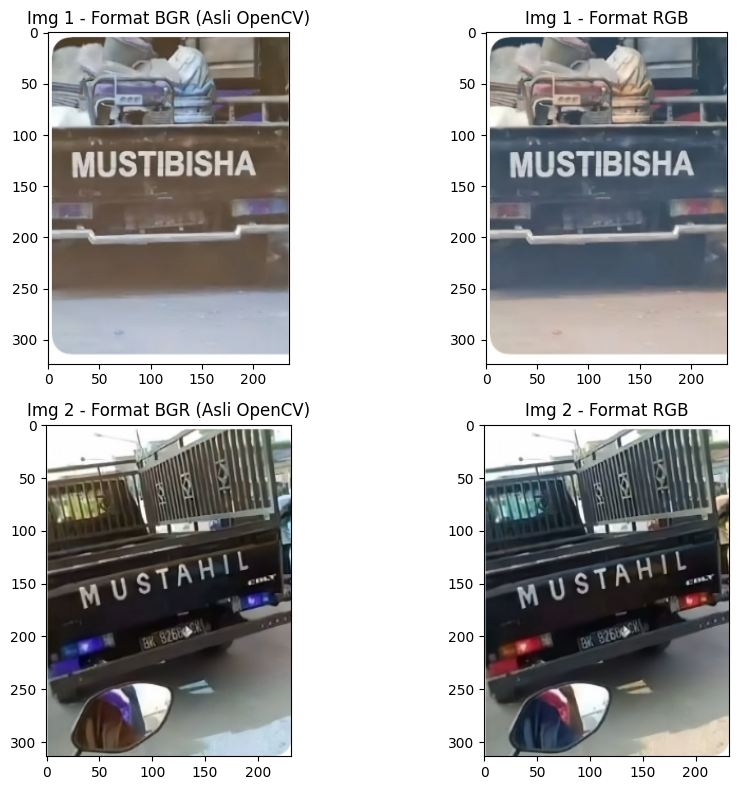

Ukuran Citra 1: (324, 236, 3) | Tipe Data: uint8
Nilai Pixel Img 1 -> Min: 36, Max: 255
Ukuran Citra 2: (314, 232, 3) | Tipe Data: uint8
Nilai Pixel Img 2 -> Min: 0, Max: 255


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1.1 Membaca Citra (Pastikan file gambar ada di folder yang sama/sesuai path)
img1 = cv.imread("/kaggle/input/datasets/abroralfarisi/testcitra/1.png")
img2 = cv.imread("/kaggle/input/datasets/abroralfarisi/testcitra/2.png")

# 1.2 Konversi BGR ke RGB
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# Menampilkan Citra Sebelum vs Sesudah Konversi
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(img1)  # Masih BGR
axs[0, 0].set_title("Img 1 - Format BGR (Asli OpenCV)")
axs[0, 1].imshow(img1_rgb)  # Sudah RGB
axs[0, 1].set_title("Img 1 - Format RGB")

axs[1, 0].imshow(img2)
axs[1, 0].set_title("Img 2 - Format BGR (Asli OpenCV)")
axs[1, 1].imshow(img2_rgb)
axs[1, 1].set_title("Img 2 - Format RGB")
plt.tight_layout()
plt.show()

# Output Informasi Citra yang Wajib Ditampilkan
print(f"Ukuran Citra 1: {img1_rgb.shape} | Tipe Data: {img1_rgb.dtype}")
print(f"Nilai Pixel Img 1 -> Min: {img1_rgb.min()}, Max: {img1_rgb.max()}")
print(f"Ukuran Citra 2: {img2_rgb.shape} | Tipe Data: {img2_rgb.dtype}")
print(f"Nilai Pixel Img 2 -> Min: {img2_rgb.min()}, Max: {img2_rgb.max()}")

**RESIZE**

Ukuran awal Img 1: (324, 236, 3) | Img 2: (314, 232, 3)
Ukuran setelah resize Img 1: (400, 600, 3) | Img 2: (400, 600, 3)


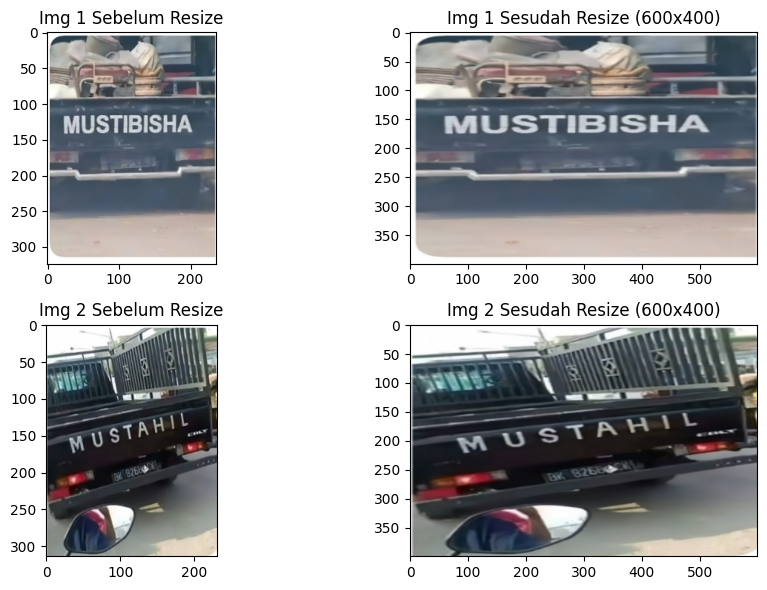

In [4]:
# Menentukan ukuran target (misal 600x400)
target_size = (600, 400)

# Cek ukuran sebelum resize
print(f"Ukuran awal Img 1: {img1_rgb.shape} | Img 2: {img2_rgb.shape}")

# Proses Resize
img1_resize = cv.resize(img1_rgb, target_size)
img2_resize = cv.resize(img2_rgb, target_size)

print(f"Ukuran setelah resize Img 1: {img1_resize.shape} | Img 2: {img2_resize.shape}")

# Tampilkan Perbandingan
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs[0, 0].imshow(img1_rgb)
axs[0, 0].set_title("Img 1 Sebelum Resize")
axs[0, 1].imshow(img1_resize)
axs[0, 1].set_title("Img 1 Sesudah Resize (600x400)")

axs[1, 0].imshow(img2_rgb)
axs[1, 0].set_title("Img 2 Sebelum Resize")
axs[1, 1].imshow(img2_resize)
axs[1, 1].set_title("Img 2 Sesudah Resize (600x400)")
plt.tight_layout()
plt.show()

**BLEND**

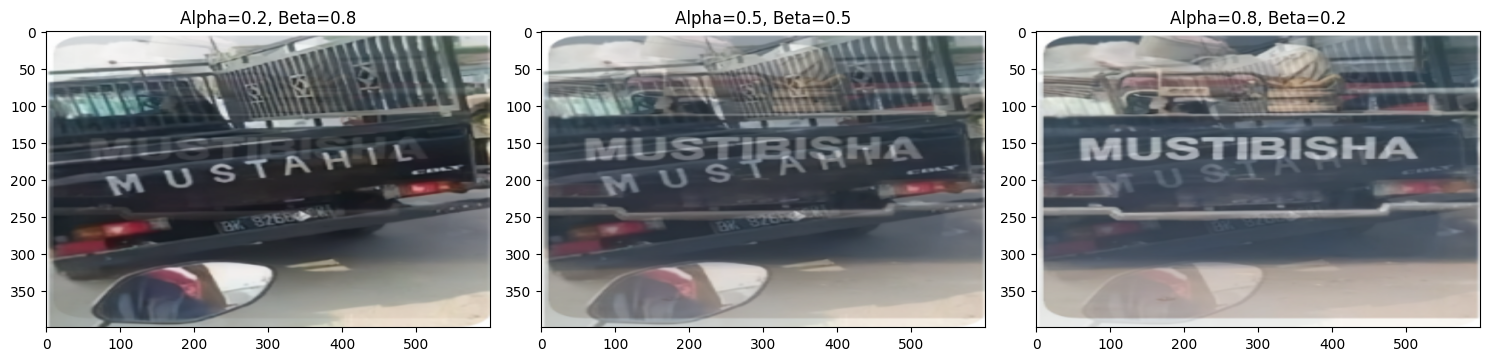

In [5]:
# Eksperimen 3 variasi bobot (alpha dan beta)
weights = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]
gamma = 0

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, (alpha, beta) in enumerate(weights):
    # Rumus: I_blend = alpha * I1 + beta * I2 + gamma
    img_blend = cv.addWeighted(img1_resize, alpha, img2_resize, beta, gamma)
    
    axs[i].imshow(img_blend)
    axs[i].set_title(f"Alpha={alpha}, Beta={beta}")

plt.tight_layout()
plt.show()

**NEGATIVE**

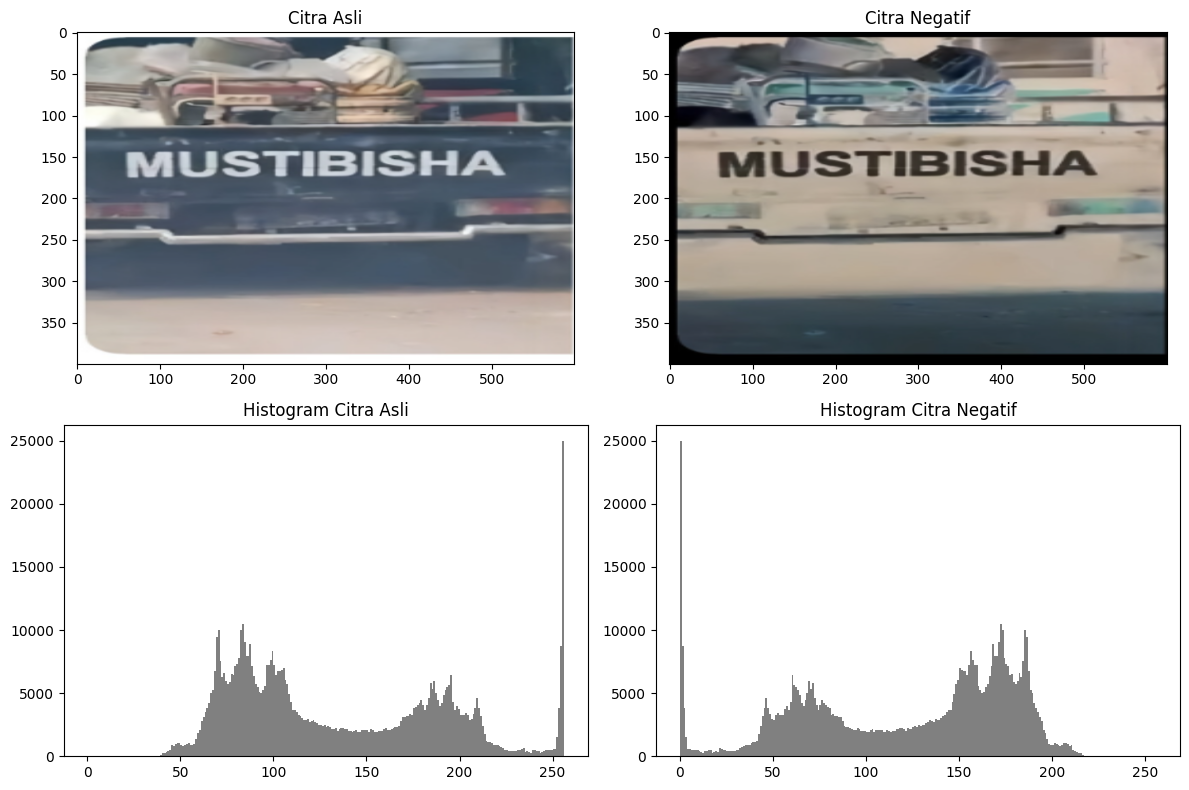

In [9]:
# 1. Operasi Negatif: Inegatif = 255 - I
img1_negative = 255 - img1_resize

# 2. Setup Plot Citra dan Histogram (2 Baris, 2 Kolom)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Tampilkan Kumpulan Citra (Baris Pertama)
axs[0, 0].imshow(img1_resize)
axs[0, 0].set_title("Citra Asli")

axs[0, 1].imshow(img1_negative)
axs[0, 1].set_title("Citra Negatif")

# Tampilkan Kumpulan Histogram (Baris Kedua)
# Menggunakan .ravel() untuk mengubah matriks 3D citra menjadi array 1D
axs[1, 0].hist(img1_resize.ravel(), bins=256, range=[0, 256], color='gray')
axs[1, 0].set_title("Histogram Citra Asli")

# FIX: Mengubah 'inverse_gray' yang error menjadi 'gray' (atau 'black')
axs[1, 1].hist(img1_negative.ravel(), bins=256, range=[0, 256], color='gray') 
axs[1, 1].set_title("Histogram Citra Negatif")

plt.tight_layout()
plt.show()

**LOG TRANSFORM**

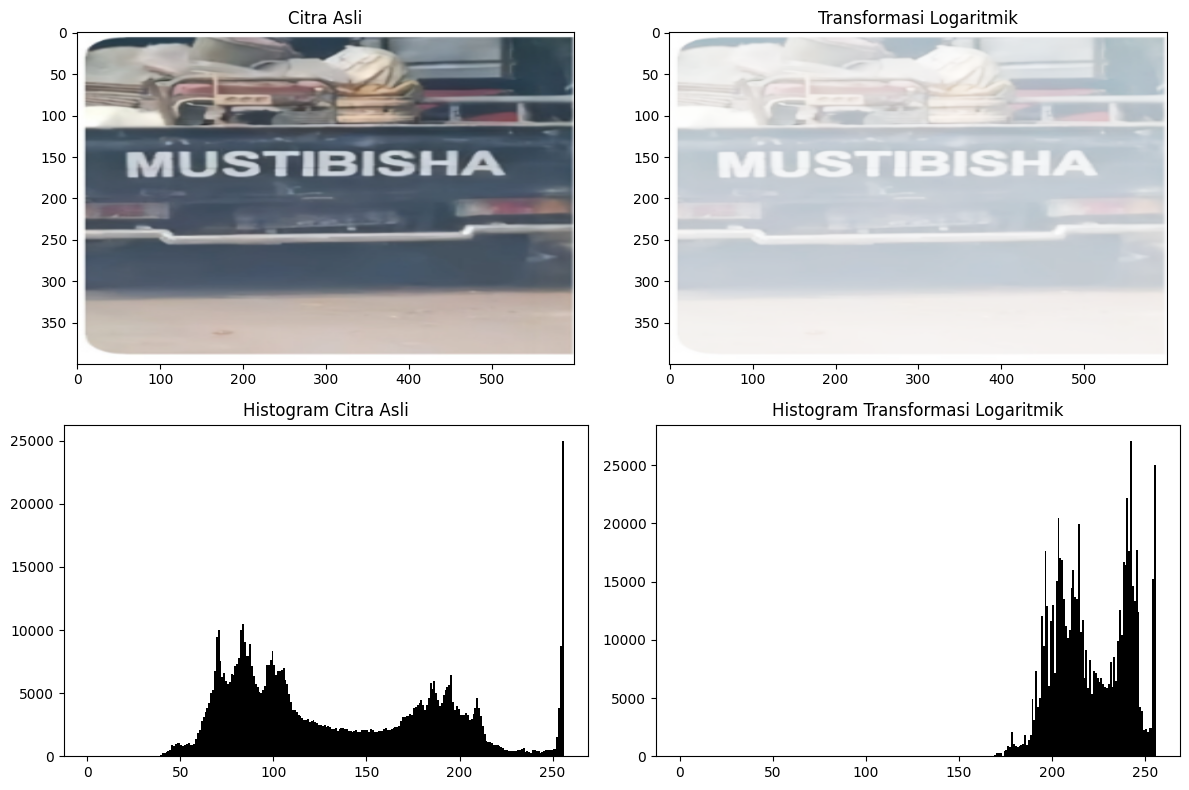

Min/Max Sebelum: 36/255
Min/Max Sesudah: 166/255


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ambil nilai max dan paksa jadi float biasa agar tidak overflow saat ditambah 1
r_max = float(np.max(img1_resize))

# 2. Hitung konstanta c dengan aman
c = 255 / np.log10(1 + r_max)

# 3. Terapkan rumus s = c * log(1 + r) 
# Pastikan gambar aslinya juga diubah ke float64 dulu saat perhitungan supaya tidak overflow
img_log = c * np.log10(img1_resize.astype(np.float64) + 1)

# 4. Kembalikan tipe data ke uint8 untuk visualisasi citra
img_log = np.array(img_log, dtype=np.uint8)

# ==========================================
# Sisa kode visualisasi histogram di bawah tetap sama
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].imshow(img1_resize)
axs[0, 0].set_title("Citra Asli")
axs[0, 1].imshow(img_log)
axs[0, 1].set_title("Transformasi Logaritmik")

axs[1, 0].hist(img1_resize.ravel(), bins=256, range=[0, 256], color='black')
axs[1, 0].set_title("Histogram Citra Asli")
axs[1, 1].hist(img_log.ravel(), bins=256, range=[0, 256], color='black')
axs[1, 1].set_title("Histogram Transformasi Logaritmik")

plt.tight_layout()
plt.show()

print(f"Min/Max Sebelum: {img1_resize.min()}/{img1_resize.max()}")
print(f"Min/Max Sesudah: {img_log.min()}/{img_log.max()}")

**GAMMA TRANSFORM**

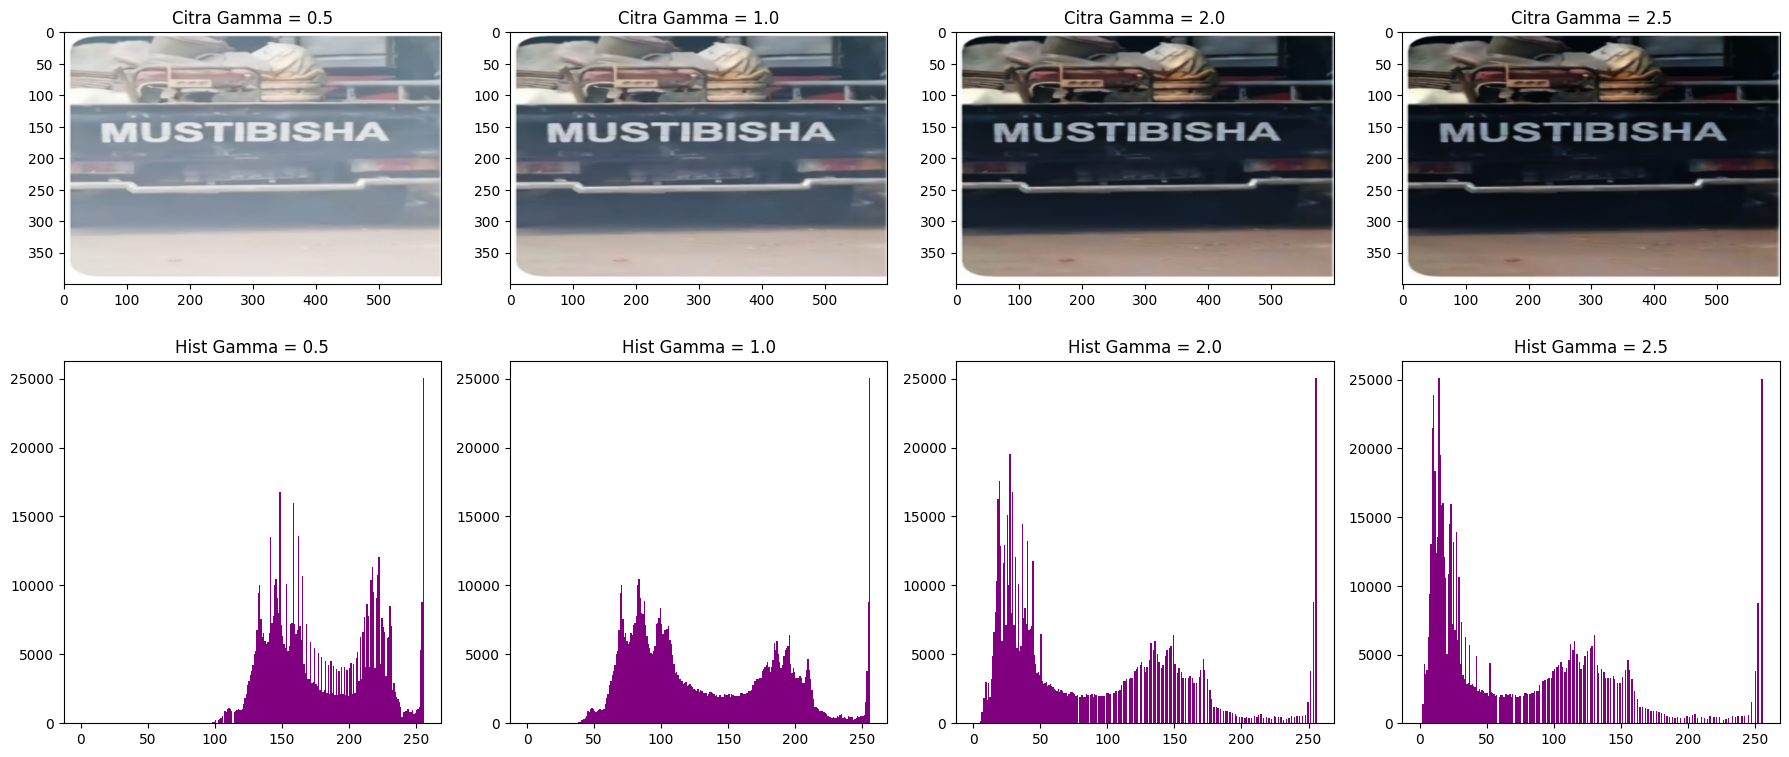

In [8]:
gammas = [0.5, 1.0, 2.0, 2.5]
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

# Normalisasi citra ke rentang [0, 1]
img_normalized = img1_resize / 255.0

for i, gamma in enumerate(gammas):
    # Rumus s = r^gamma
    img_gamma = np.power(img_normalized, gamma)
    # Kembalikan ke rentang [0, 255]
    img_gamma = np.array(img_gamma * 255, dtype=np.uint8)
    
    # Tampilkan gambar
    axs[0, i].imshow(img_gamma)
    axs[0, i].set_title(f"Citra Gamma = {gamma}")
    
    # Tampilkan histogram
    axs[1, i].hist(img_gamma.ravel(), bins=256, range=[0, 256], color='purple')
    axs[1, i].set_title(f"Hist Gamma = {gamma}")

plt.tight_layout()
plt.show()